<a href="https://colab.research.google.com/github/kislayanand1803/customer-retention-insights/blob/main/Churn_Probability_%26_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [ ]:
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [ ]:
df.shape

(7043, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


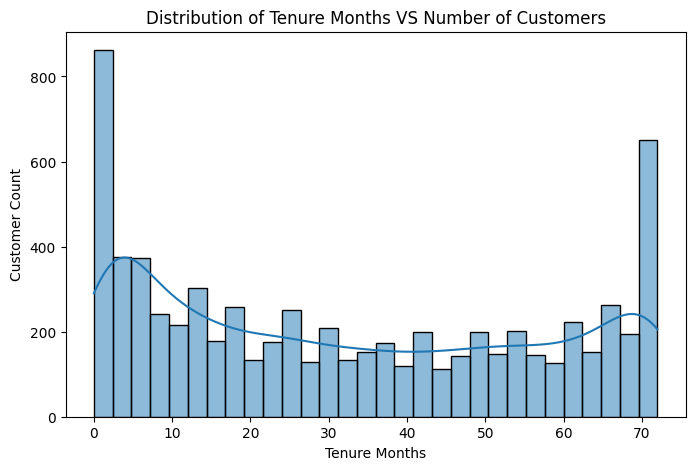

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins=30, kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer Count')
plt.title('Distribution of Tenure Months VS Number of Customers')
plt.show()

In [ ]:
df['Tenure Months'].max()

72

In [ ]:
df['Tenure Months'].min()

0

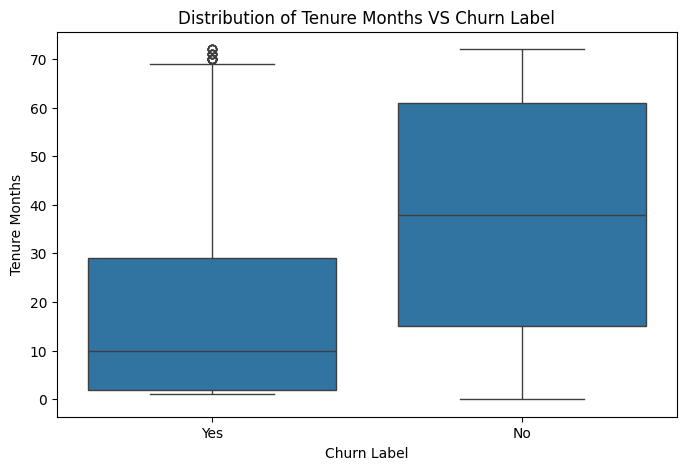

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Tenure Months', data=df)
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Distribution of Tenure Months VS Churn Label')
plt.show()

In [ ]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df[df['Churn Label']=='Yes']

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,1699-HPSBG,1,United States,California,Palm Springs,92264,"33.745746, -116.514215",33.745746,-116.514215,Male,...,One year,Yes,Electronic check,59.80,727.8,Yes,1,69,4581,Competitor offered higher download speeds
1865,8775-CEBBJ,1,United States,California,Seeley,92273,"32.790282, -115.689559",32.790282,-115.689559,Female,...,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes,1,87,2029,Competitor offered higher download speeds
1866,6894-LFHLY,1,United States,California,Vidal,92280,"34.264124, -114.717964",34.264124,-114.717964,Male,...,Month-to-month,Yes,Electronic check,75.75,75.75,Yes,1,97,5571,Competitor offered higher download speeds
1867,0639-TSIQW,1,United States,California,White Water,92282,"33.972293, -116.654195",33.972293,-116.654195,Female,...,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes,1,70,5620,Competitor offered more data


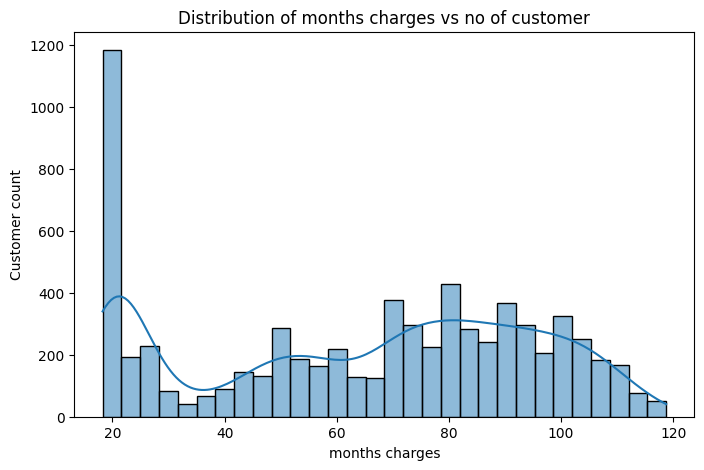

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.xlabel('months charges')
plt.ylabel('Customer count')
plt.title('Distribution of months charges vs no of customer')
plt.show()

In [ ]:
df['Monthly Charges'].max()

118.75

In [ ]:
df['Monthly Charges'].min()

18.25

In [ ]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [ ]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [ ]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [ ]:
df['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [ ]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [ ]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


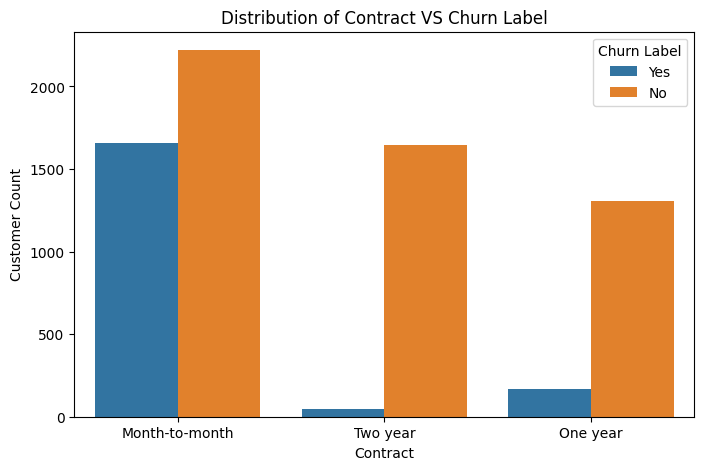

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.xlabel('Contract')
plt.ylabel('Customer Count')
plt.title('Distribution of Contract VS Churn Label')
plt.show()

In [ ]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

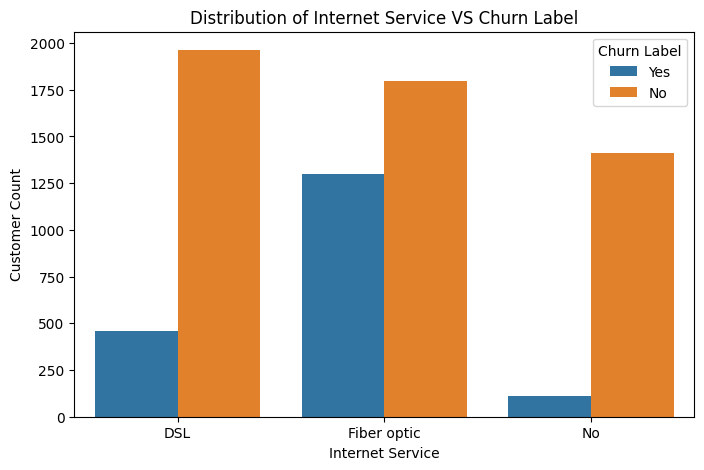

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.xlabel('Internet Service')
plt.ylabel('Customer Count')
plt.title('Distribution of Internet Service VS Churn Label')
plt.show()

In [ ]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

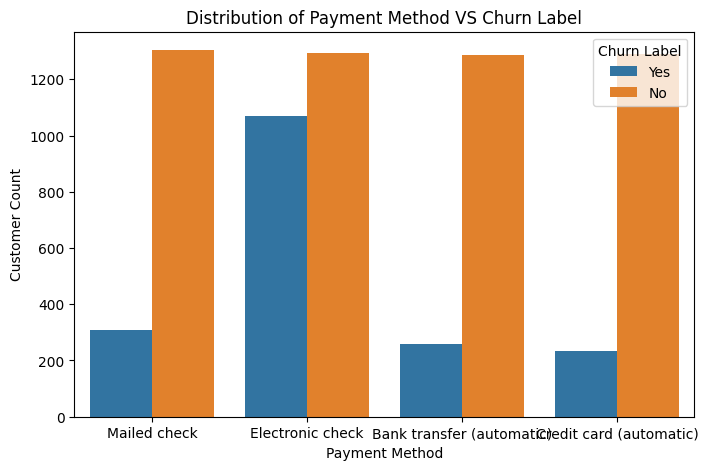

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method', hue='Churn Label', data=df)
plt.xlabel('Payment Method')
plt.ylabel('Customer Count')
plt.title('Distribution of Payment Method VS Churn Label')
plt.show()

In [ ]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

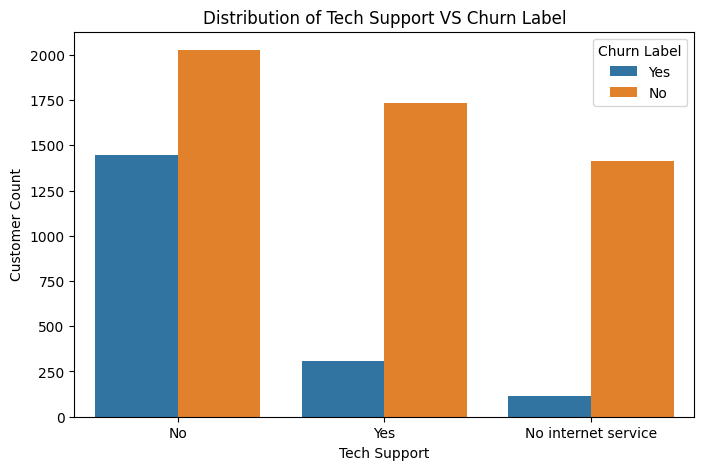

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support', hue='Churn Label', data=df)
plt.xlabel('Tech Support')
plt.ylabel('Customer Count')
plt.title('Distribution of Tech Support VS Churn Label')
plt.show()

In [ ]:
avg_tenure=df.groupby('Churn Label')['Tenure Months'].mean()
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [ ]:
numerical_col=['Tenure Months','Monthly Charges','Churn Value','Churn Score','CLTV']
correlation_matrix=df[numerical_col].corr()
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


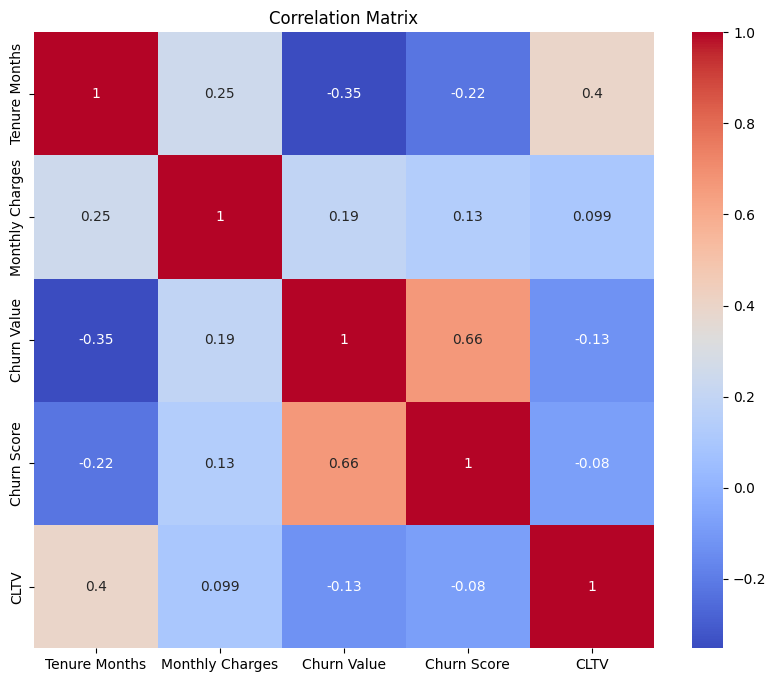

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
contract_churn=pd.crosstab(df['Contract'], df['Churn Label'],normalize='index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


**Data Cleaning**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [ ]:
pd.to_numeric(df['Total Charges'], errors='coerce')

,Total Charges
0,108.15
1,151.65
2,820.50
3,3046.05
4,5036.30
...,...
7038,1419.40
7039,1990.50
7040,7362.90
7041,346.45


In [ ]:
df['Total Charges'].dtype

dtype('O')

In [ ]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months


In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(0,)

In [ ]:
df['Total Charges']=df['Total Charges'].fillna(0)

In [ ]:
df.shape

(7043, 33)

In [ ]:
drop_column = ['CustomerID', 'Count', 'Country', 'State', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason']

In [ ]:
df = df.drop(columns=drop_column)

In [ ]:
df['City'].unique()
df['City'].value_counts()

,count
City,
Los Angeles,305
San Diego,150
San Jose,112
Sacramento,108
San Francisco,104
...,...
Chester,4
Big Bar,4
Washington,4


In [ ]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [ ]:
df_encoded.head()

,Tenure Months,Monthly Charges,Churn Value,City_Acton,City_Adelanto,City_Adin,City_Agoura Hills,City_Aguanga,City_Ahwahnee,City_Alameda,...,Total Charges_8496.7,Total Charges_8529.5,Total Charges_8543.25,Total Charges_8547.15,Total Charges_8564.75,Total Charges_8594.4,Total Charges_8670.1,Total Charges_8672.45,Total Charges_8684.8,Total Charges_
0,2,53.85,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,70.70,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,8,99.65,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,28,104.80,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,49,103.70,1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df_encoded.shape

(7043, 7688)

In [ ]:
df=df.drop(columns=['City'])

In [ ]:
df.shape

(7043, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [ ]:
x=df_encoded.drop(columns=['Churn Value'])
y=df_encoded['Churn Value']

In [ ]:
x.shape
y.shape

(7043,)

Machine Learning Implementation

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(5634, 7687)

In [ ]:
y_train.shape

(5634,)

In [ ]:
X_test.shape

(1409, 7687)

In [ ]:
y_test.shape

(1409,)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
y_pred

array([0, 0, 0, ..., 0, 0, 1])

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
accuracy=accuracy_score(y_test, y_pred)
accuracy

0.7970191625266146

In [ ]:
print(confusion_matrix(y_test, y_pred))

[[927  82]
 [204 196]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1009
           1       0.71      0.49      0.58       400

    accuracy                           0.80      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.79      0.80      0.78      1409



Approach 1 - Handle Class Imbalance

In [ ]:
rf_balanced=RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_balanced.fit(X_train, y_train)
y_pred_balanced=rf_balanced.predict(X_test)
accuracy_balanced=accuracy_score(y_test, y_pred_balanced)
cm_balanced=confusion_matrix(y_test, y_pred_balanced)
cr_balanced=classification_report(y_test, y_pred_balanced)
print("Accuracy:", accuracy_balanced)
print("Confusion Matrix:\n", cm_balanced)
print("Classification Report:\n", cr_balanced)

Accuracy: 0.8055358410220014
Confusion Matrix:
 [[907 102]
 [172 228]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1009
           1       0.69      0.57      0.62       400

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.75      1409
weighted avg       0.80      0.81      0.80      1409



Approach 2 - Hyperparameter Tuning

In [ ]:
rf_tuned=RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_tuned.fit(X_train, y_train)
y_pred_tuned=rf_tuned.predict(X_test)
accuracy_tuned=accuracy_score(y_test, y_pred_tuned)
cm_tuned=confusion_matrix(y_test, y_pred_tuned)
cr_tuned=classification_report(y_test, y_pred_tuned)
print("Accuracy:", accuracy_tuned)
print("Confusion Matrix:\n", cm_tuned)
print("Classification Report:\n", cr_tuned)

Accuracy: 0.7132718239886444
Confusion Matrix:
 [[667 342]
 [ 62 338]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.66      0.77      1009
           1       0.50      0.84      0.63       400

    accuracy                           0.71      1409
   macro avg       0.71      0.75      0.70      1409
weighted avg       0.80      0.71      0.73      1409



Approach 3 - Feature Importance Analysis

In [ ]:
import pandas as pd
feature_importance = pd.DataFrame({'Feature': x.columns, 'Importance': rf_tuned.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

                                    Feature  Importance
0                             Tenure Months    0.086571
1152                      Contract_Two year    0.079860
1155        Payment Method_Electronic check    0.050875
1143  Device Protection_No internet service    0.045841
1                           Monthly Charges    0.045651
...                                     ...         ...
2224                   Total Charges_272.15    0.000000
4460                  Total Charges_1588.25    0.000000
4459                  Total Charges_1587.55    0.000000
4455                  Total Charges_1581.95    0.000000
608                       City_Meadow Vista    0.000000

[7687 rows x 2 columns]


In [ ]:
X_selected = x.drop(['Phone Service_Yes', 'Multiple Lines_No phone service'], axis = 1)

In [ ]:
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_selected, y, test_size=0.2, random_state=42)
#

In [ ]:
rf_selected = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_selected.fit(X_train_sel, y_train_sel)
y_pred_selected = rf_selected.predict(X_test_sel)
accuracy_selected = accuracy_score(y_test_sel, y_pred_selected)
print("Accuracy:", accuracy_selected)
print("Confusion Matrix:\n", confusion_matrix(y_test_sel, y_pred_selected))
print(classification_report(y_test_sel, y_pred_selected))

Accuracy: 0.7203690560681334
Confusion Matrix:
 [[681 328]
 [ 66 334]]
              precision    recall  f1-score   support

           0       0.91      0.67      0.78      1009
           1       0.50      0.83      0.63       400

    accuracy                           0.72      1409
   macro avg       0.71      0.75      0.70      1409
weighted avg       0.80      0.72      0.73      1409



Approach Combination of Trees & Depth

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score

In [ ]:
n_estimators_list = [100, 200, 300, 400, 500]
max_depth_list = [5, 10, 15, 20]
results = []
for n_trees in n_estimators_list:
    for depth in max_depth_list:
        rf = RandomForestClassifier(n_estimators=n_trees, max_depth=depth, random_state=42, class_weight='balanced')
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        results.append({'Trees': n_trees, 'Depth': depth, 'Accuracy': accuracy, 'Recall': recall, 'Precision': precision, 'F1 Score': f1})
results_df = pd.DataFrame(results)
result_df = results_df.sort_values(by=['Recall','Accuracy'], ascending=False)
print(result_df.head(20))

    Trees  Depth  Accuracy  Recall  Precision  F1 Score
12    400      5  0.682044  0.8850   0.468254  0.612457
16    500      5  0.687722  0.8775   0.473046  0.614711
8     300      5  0.679915  0.8725   0.465955  0.607485
4     200      5  0.666430  0.8700   0.454308  0.596913
0     100      5  0.690561  0.8600   0.475138  0.612100
17    500     10  0.717530  0.8575   0.501462  0.632841
13    400     10  0.716111  0.8550   0.500000  0.630996
9     300     10  0.713272  0.8450   0.497059  0.625926
5     200     10  0.702626  0.8400   0.486252  0.615949
1     100     10  0.718240  0.8375   0.502249  0.627929
18    500     15  0.731015  0.8325   0.516279  0.637321
14    400     15  0.728176  0.8325   0.513097  0.634890
10    300     15  0.731725  0.8300   0.517134  0.637236
6     200     15  0.727466  0.8250   0.512422  0.632184
2     100     15  0.733144  0.8225   0.518927  0.636364
11    300     20  0.741661  0.8150   0.529221  0.641732
7     200     20  0.739532  0.8125   0.526742  0

In [ ]:
from sklearn.model_selection import cross_val_score
final_rf = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, class_weight='balanced')

In [ ]:
cv_accuracy = cross_val_score(final_rf, x, y, cv=5, scoring='accuracy')

In [ ]:
cv_accuracy

array([0.76366217, 0.75869411, 0.72746629, 0.74076705, 0.73721591])

In [ ]:
cv_accuracy.mean()

np.float64(0.7455611047486934)

In [ ]:
cv_recall = cross_val_score(final_rf, x, y, cv=5, scoring='recall')

In [ ]:
cv_recall

array([0.85026738, 0.82887701, 0.79946524, 0.79946524, 0.77747989])

In [ ]:
cv_recall.mean()

np.float64(0.8111109518143108)

Optional

In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, roc_curve

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
y_prob = rf_tuned.predict_proba(x)

In [ ]:
y_prob1 = rf_tuned.predict_proba(X_test)

In [ ]:
churn_prob = y_prob[:,1]

In [ ]:
churn_prob1 = y_prob1[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, churn_prob1)
auc_score = roc_auc_score(y_test,churn_prob1)
print("AUC Score:", auc_score)

AUC Score: 0.8274640733399404


**Customer Segmentation**

In [ ]:
segmentation_data = pd.DataFrame({
  'Tenure Months': x['Tenure Months'],
  'Monthly Charges': x['Monthly Charges'],
  'Total Charges': pd.to_numeric(df['Total Charges'], errors='coerce').fillna(0),
  'Churn Probability': churn_prob
})

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.537470
1,2,70.70,151.65,0.604960
2,8,99.65,820.50,0.597821
3,28,104.80,3046.05,0.527659
4,49,103.70,5036.30,0.515150
...,...,...,...,...
7038,72,21.15,1419.40,0.266973
7039,24,84.80,1990.50,0.422381
7040,72,103.20,7362.90,0.445082
7041,11,29.60,346.45,0.517231


Implementation of KMeans

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(segmentation_data)
print(scaled_data)

[[-1.23672422 -0.36266036 -0.9580659   0.58357966]
 [-1.23672422  0.19736523 -0.93887444  1.12270081]
 [-0.99240204  1.1595457  -0.64378925  1.06567174]
 ...
 [ 1.61370124  1.27753328  2.24260588 -0.15441892]
 [-0.87024095 -1.1686319  -0.85293201  0.42191377]
 [ 1.36937906  1.35896134  2.01389665 -0.11684388]]


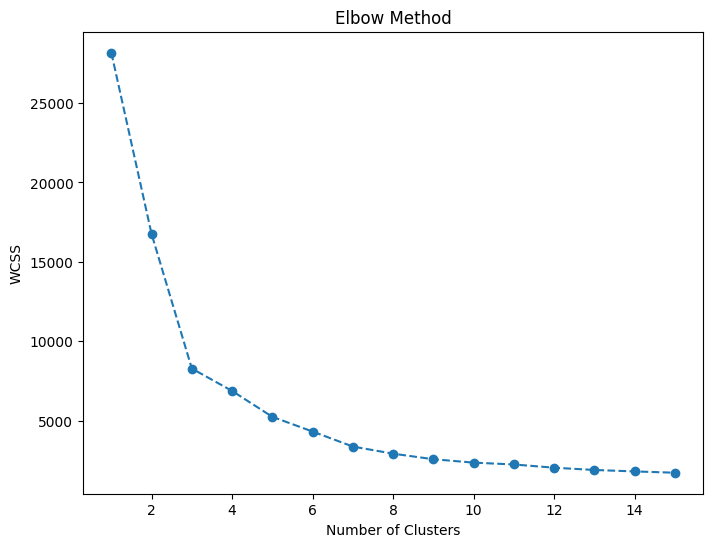

In [ ]:
wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,6))
plt.plot(range(1,16), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters=kmeans.fit_predict(scaled_data)

In [ ]:
segmentation_data['Cluster'] = clusters
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
0,2,53.85,108.15,0.537470,1
1,2,70.70,151.65,0.604960,1
2,8,99.65,820.50,0.597821,1
3,28,104.80,3046.05,0.527659,1
4,49,103.70,5036.30,0.515150,2
...,...,...,...,...,...
7038,72,21.15,1419.40,0.266973,0
7039,24,84.80,1990.50,0.422381,1
7040,72,103.20,7362.90,0.445082,2
7041,11,29.60,346.45,0.517231,1


In [ ]:
cluster_summary = segmentation_data.groupby('Cluster').mean()
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,31.624113,23.017051,762.648109,0.286019
1,13.720455,70.031315,985.720211,0.563495
2,58.222369,88.716557,5165.015346,0.462947


In [ ]:
cluster_names={
    0:'Budget Loyal Customers',
    1:'High Risk New Customers',
    2:'Premium Loyal Customers'
}

In [ ]:
segmentation_data['Cluster Segmentation']=segmentation_data['Cluster'].map(cluster_names)
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segmentation
0,2,53.85,108.15,0.537470,1,High Risk New Customers
1,2,70.70,151.65,0.604960,1,High Risk New Customers
2,8,99.65,820.50,0.597821,1,High Risk New Customers
3,28,104.80,3046.05,0.527659,1,High Risk New Customers
4,49,103.70,5036.30,0.515150,2,Premium Loyal Customers
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.266973,0,Budget Loyal Customers
7039,24,84.80,1990.50,0.422381,1,High Risk New Customers
7040,72,103.20,7362.90,0.445082,2,Premium Loyal Customers
7041,11,29.60,346.45,0.517231,1,High Risk New Customers


Text(0.5, 1.0, 'Customer Segmentation')

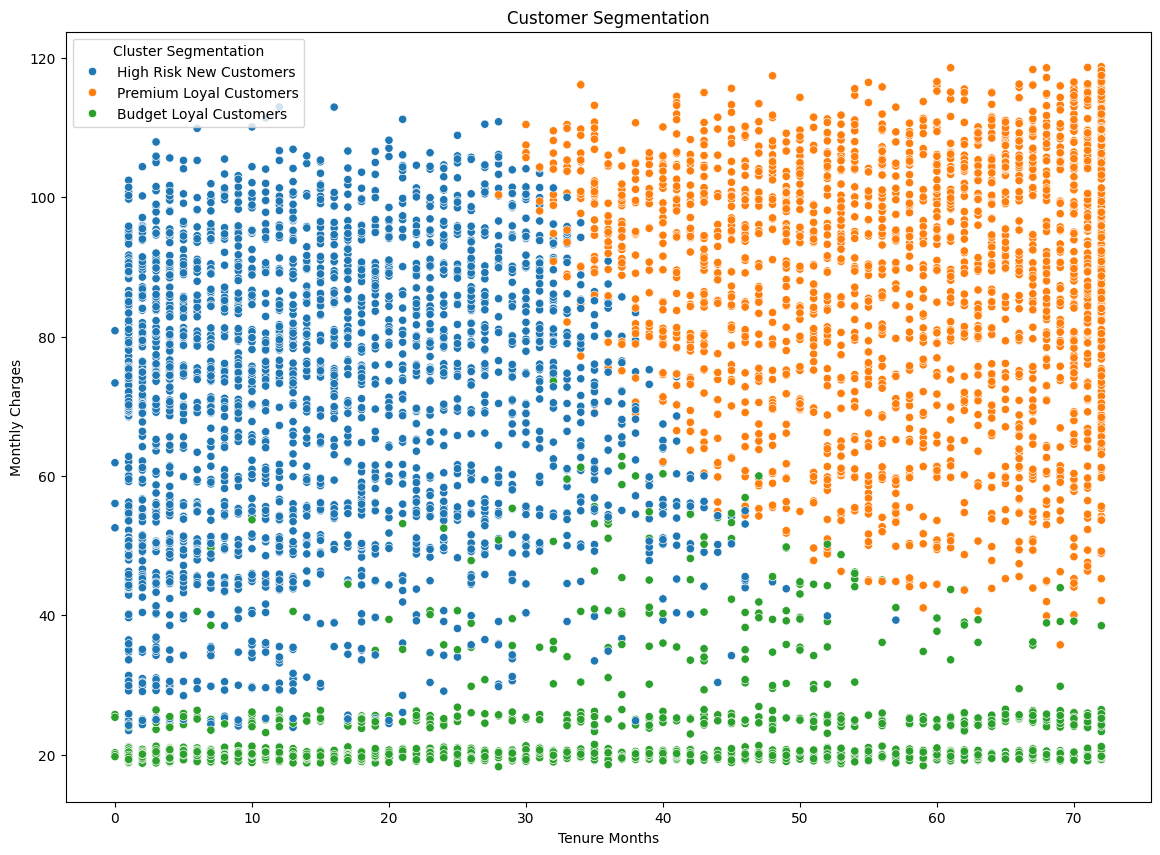

In [ ]:
plt.figure(figsize=(14,10))
sns.scatterplot(x='Tenure Months', y='Monthly Charges', hue='Cluster Segmentation', data=segmentation_data)
plt.xlabel('Tenure Months')
plt.ylabel('Monthly Charges')
plt.title('Customer Segmentation')

Text(0.5, 1.0, 'Customer Segmentation')

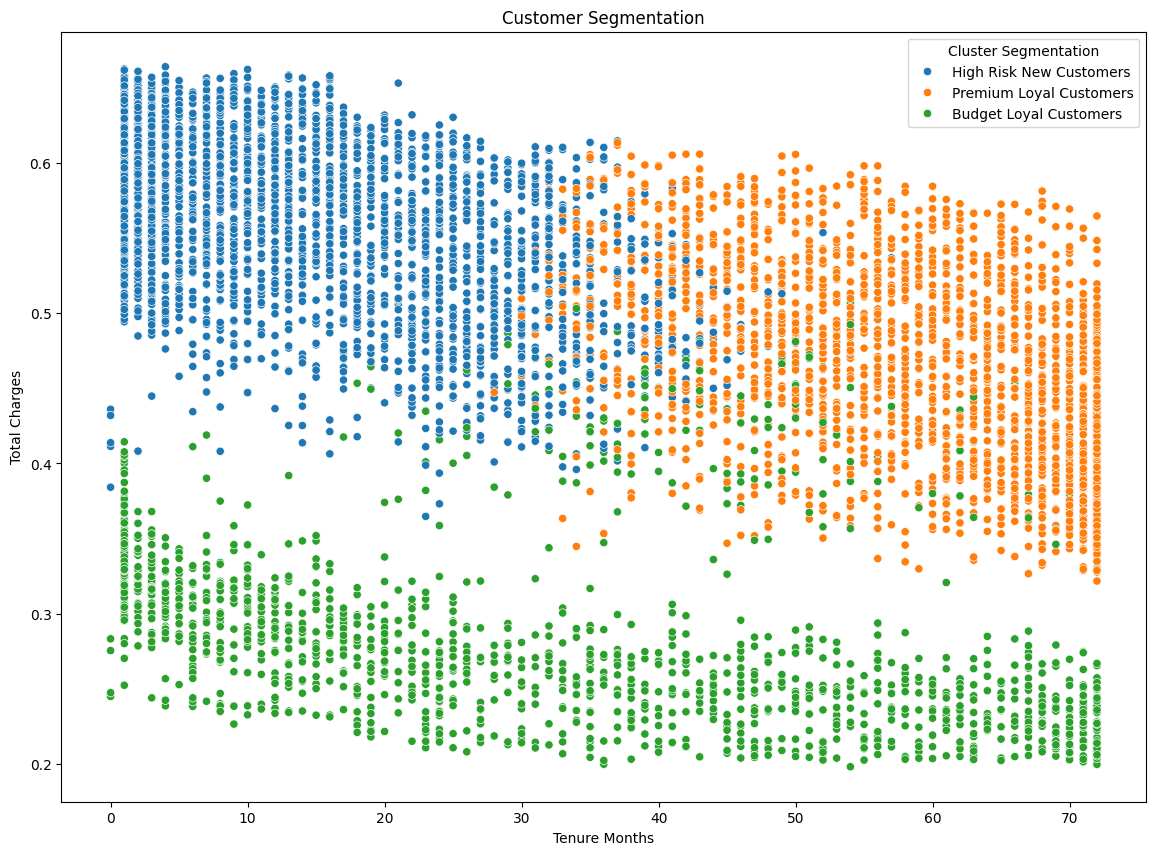

In [ ]:
plt.figure(figsize=(14,10))
sns.scatterplot(x='Tenure Months', y='Churn Probability', hue='Cluster Segmentation', data=segmentation_data)
plt.xlabel('Tenure Months')
plt.ylabel('Total Charges')
plt.title('Customer Segmentation')
#

Text(0.5, 1.0, 'Customer Segmentation')

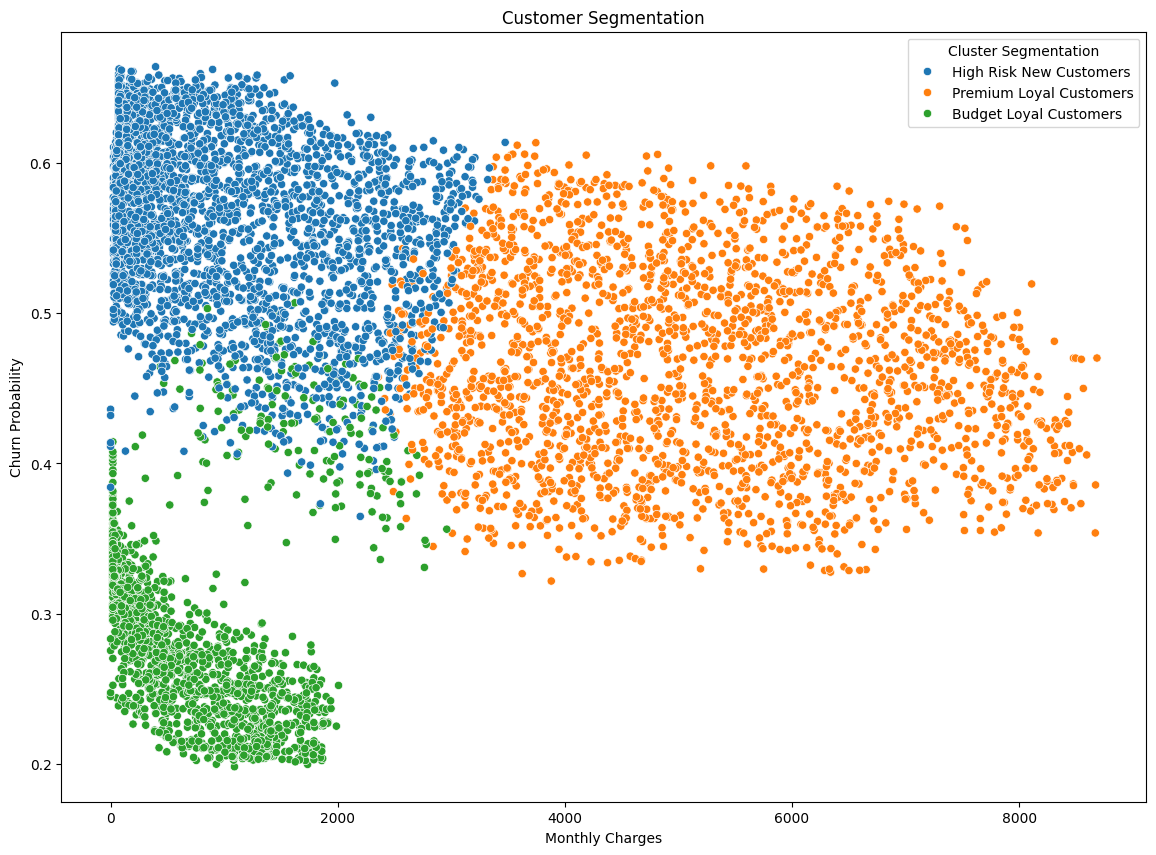

In [ ]:
plt.figure(figsize=(14,10))
sns.scatterplot(x='Total Charges', y='Churn Probability', hue='Cluster Segmentation', data=segmentation_data)
plt.xlabel('Monthly Charges')
plt.ylabel('Churn Probability')
plt.title('Customer Segmentation')
#